In [1]:
%reload_ext autoreload
%autoreload 2

In [1]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import Ball, Stick, Zeppelin, Dti, BallStick, Ball2Stick, AllGaussianModels
from dmri.simulators.acquisition_scheme import acquisition_scheme, random_hardi_acquisition, random_clinical_acquisition, random_advanced_reasearch_acquisition_scheme
from dmri.simulators.multi_compartment import AllGaussianAndConvolvedModels
from flax import nnx


ball_stick = AllGaussianAndConvolvedModels.from_theta(np.random.randn(AllGaussianAndConvolvedModels.theta_dim))

/weka/macke/mgloeckler90/simformer_model_selection/dmri/dmri/simulators/sphereical_distributions.py:20: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  sphere_default = get_sphere("symmetric724")
/weka/macke/mgloeckler90/simformer_model_selection/dmri/dmri/simulators/sphereical_distributions.py:23: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  big_sphere = get_sphere("repulsion724")


In [2]:

def simulator_hardi(rng):
    rng0, rng1, rng2, rng3, rng4, rng5, rng6, rng7 = jax.random.split(rng, 8)
    acq = random_hardi_acquisition(rng0)
    theta = jax.random.normal(rng1, shape=(AllGaussianAndConvolvedModels.theta_dim,))
    p = jax.random.beta(rng2, 1.0, 1.0, shape=(1,))
    model_mask = jax.random.bernoulli(rng3, p=p, shape=(len(AllGaussianAndConvolvedModels.model_types)))
    # This needs to have only one entry
    model_noise_idx = jax.random.randint(rng4, minval=0, maxval=len(AllGaussianAndConvolvedModels.noise_types), shape=(1,))
    model_noise_mask = jnp.zeros(len(AllGaussianAndConvolvedModels.noise_types), dtype=jnp.bool)
    model_noise_mask = model_noise_mask.at[model_noise_idx].set(True)
    model_mask = jnp.concatenate([model_mask, model_noise_mask], axis=-1)

    ball_stick = AllGaussianAndConvolvedModels.from_theta(theta, model_mask=model_mask)

    x_o = ball_stick.signal(acq, rng=rng5)
    return p,model_mask, theta, x_o, acq


def simulator_clinical(rng):
    rng0, rng1, rng2, rng3, rng4, rng5, rng6, rng7 = jax.random.split(rng, 8)
    acq = random_clinical_acquisition(rng0)
    theta = jax.random.normal(rng1, shape=(AllGaussianAndConvolvedModels.theta_dim,))
    p = jax.random.beta(rng2, 1.0, 1.0, shape=(1,))
    model_mask = jax.random.bernoulli(rng3, p=p, shape=(len(AllGaussianAndConvolvedModels.model_types)))
    # This needs to have only one entry
    model_noise_idx = jax.random.randint(rng4, minval=0, maxval=len(AllGaussianAndConvolvedModels.noise_types), shape=(1,))
    model_noise_mask = jnp.zeros(len(AllGaussianAndConvolvedModels.noise_types), dtype=jnp.bool)
    model_noise_mask = model_noise_mask.at[model_noise_idx].set(True)
    model_mask = jnp.concatenate([model_mask, model_noise_mask], axis=-1)

    ball_stick = AllGaussianAndConvolvedModels.from_theta(theta, model_mask=model_mask)

    x_o = ball_stick.signal(acq, rng=rng5)
    return p,model_mask, theta, x_o, acq


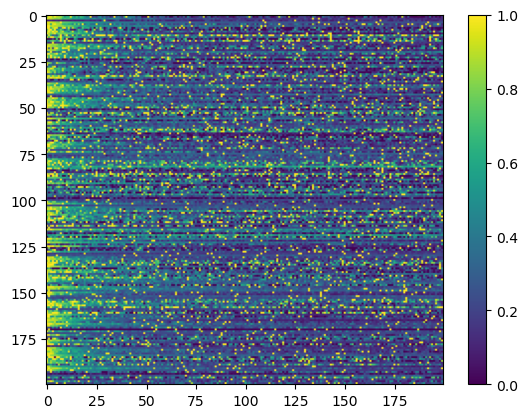

In [3]:
p_mask,masks, theta, x_o, acq = jax.vmap(simulator_hardi)(jax.random.split(jax.random.PRNGKey(0), num=200))

plt.imshow(x_o, aspect='auto', vmin=0, vmax=1)
plt.colorbar()

In [4]:
from dmri.nn.dmri_reconstruction_model import DMRIInferenceModel, DMRIInferenceModelConfig, DMRIInferenceModelConfigMaskPriorAmortized

cfg = DMRIInferenceModelConfigMaskPriorAmortized(AllGaussianAndConvolvedModels)
cfg.model_dim = 128

model = DMRIInferenceModel(cfg, nnx.Rngs(1))

params = nnx.state(model, nnx.Param)


In [5]:
nnx.display(model)

In [6]:
import optax


optimizer = optax.chain(optax.adaptive_grad_clip(10.), optax.adamw(5e-4))

opt_state = optimizer.init(params)


In [7]:

def loss_fn(params, data, rng):
    rng1, rng2 = jnp.split(rng, 2)
    p_mask,mask, thetas,  xs, bvals, bvecs = data[0]
    loss1 = model.loss_fn(params,rng1, mask, thetas, xs, bvals,bvecs, mask_prior=p_mask).sum()
    p_mask,mask, thetas,  xs, bvals, bvecs = data[1]
    loss2 = model.loss_fn(params,rng2, mask, thetas, xs, bvals,bvecs, mask_prior=p_mask).sum()
    return 0.5*(loss1*loss2)


@jax.jit
def update(params, opt_state, data, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, data, rng)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [8]:
batch_simulator = jax.jit(jax.vmap(simulator_hardi))

In [9]:
batch_simulator2 = jax.jit(jax.vmap(simulator_clinical))

In [10]:
key = jax.random.key(521)
for i in range(200):
    key, subkey1 = jax.random.split(key, 2)

    p_mask, masks, thetas, x_os, acq = batch_simulator(jax.random.split(subkey1, 2**12))
    p_mask2, masks2, thetas2, x_os2, acq2 = batch_simulator2(jax.random.split(subkey1, 2**13))
    l = 0
    for j in range(100):
        key, subkey2 = jax.random.split(key, 2)
        idx = jax.random.randint(subkey2, (512,), 0, 2**12)
        idx2 = jax.random.randint(subkey2, (512,), 0, 2**13)
        alphas_batch,masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch =p_mask[idx], masks[idx], thetas[idx], x_os[idx], acq.bvals[idx], acq.bvecs[idx]
        alphas_batch2,masks_batch2, thetas_batch2, x_os_batch2, bvals_batch2, bvecs_batch2 =p_mask2[idx2], masks2[idx2], thetas2[idx2], x_os2[idx2], acq2.bvals[idx2], acq2.bvecs[idx2]
        data = ((alphas_batch, masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch), (alphas_batch2, masks_batch2, thetas_batch2, x_os_batch2, bvals_batch2, bvecs_batch2))
        params, opt_state, loss = update(params, opt_state, data, subkey2)
        l += loss
    print(l/100)

2025-02-22 07:34:42.540002: W external/xla/xla/hlo/transforms/simplifiers/hlo_rematerialization.cc:3021] Can't reduce memory use below 56.35GiB (60508440120 bytes) by rematerialization; only reduced to 58.62GiB (62946329520 bytes), down from 58.63GiB (62949312136 bytes) originally


(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41)
(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41)
738.5219
616.1533
608.11584
606.3705
604.53613
606.3504
595.5517
589.94037
582.2422
575.9883
569.5626
562.46185
560.06903
558.22076
558.2551
551.7927
553.2529
551.173
554.45483
552.2803
545.241
552.9376
547.1108
551.974


KeyboardInterrupt: 

In [24]:
nnx.update(model, params)

In [25]:
import pickle

with open('params_big_large_mask.pkl', 'wb') as f:
    pickle.dump(params, f)

In [58]:
# import pickle
# with open('params.pkl', 'rb') as f:
#     params = pickle.load(f)
#     nnx.update(model.encoder, params[0])
#     nnx.update(model.model_decoder, params[1])
#     nnx.update(model.inference_decoder, params[2])

In [15]:
#alphas,masks, thetas, x_os, bvals, bevecs = batch_simulator(jax.random.split(jax.random.key(0), 2**10))

In [11]:
idx = 20
p_mask[idx]

Array([0.987], dtype=float32)

In [ ]:
from dmri.utils.eval import run_tarp

_sample_mask_batched =jax.vmap(model.sample_mask, in_axes=(None,0,0, 0,0))
_sample_mask_batched_batched = jax.vmap(_sample_mask_batched, in_axes=(0,None,None, None, None))

masks_per_obs = _sample_mask_batched_batched(jax.random.split(jax.random.key(0), 64), acq.bvals, acq.bvecs, x_os, p_mask)

UnexpectedTracerError: Encountered an unexpected tracer. A function transformed by JAX had a side effect, allowing for a reference to an intermediate value with type float32[2,1] wrapped in a JVPTracer to escape the scope of the transformation.
JAX transformations require that functions explicitly return their outputs, and disallow saving intermediate values to global state.
To catch the leak earlier, try setting the environment variable JAX_CHECK_TRACER_LEAKS or using the `jax.checking_leaks` context manager.
See https://jax.readthedocs.io/en/latest/errors.html#jax.errors.UnexpectedTracerError

: 

In [34]:
ecd, alpha = run_tarp(masks.astype(jnp.float32), masks_per_obs.astype(jnp.float32), num_bins=20)

(64, 4096) (4096,)


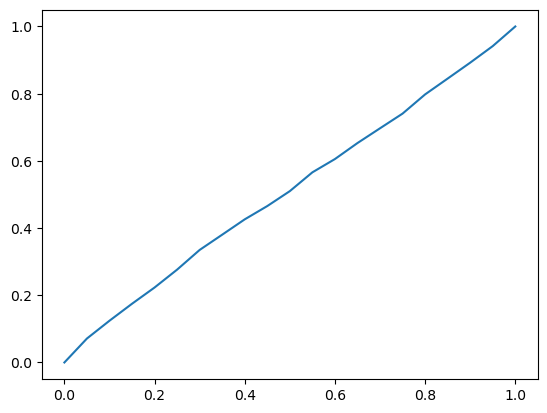

In [35]:
plt.plot(alpha,ecd)

In [36]:
masks_per_obs.shape

(64, 4096, 42)

In [50]:
mask = jax.vmap(model.sample_mask, in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 32), acq.bvals[idx], acq.bvecs[idx], x_os[idx], jnp.array([0.2]))

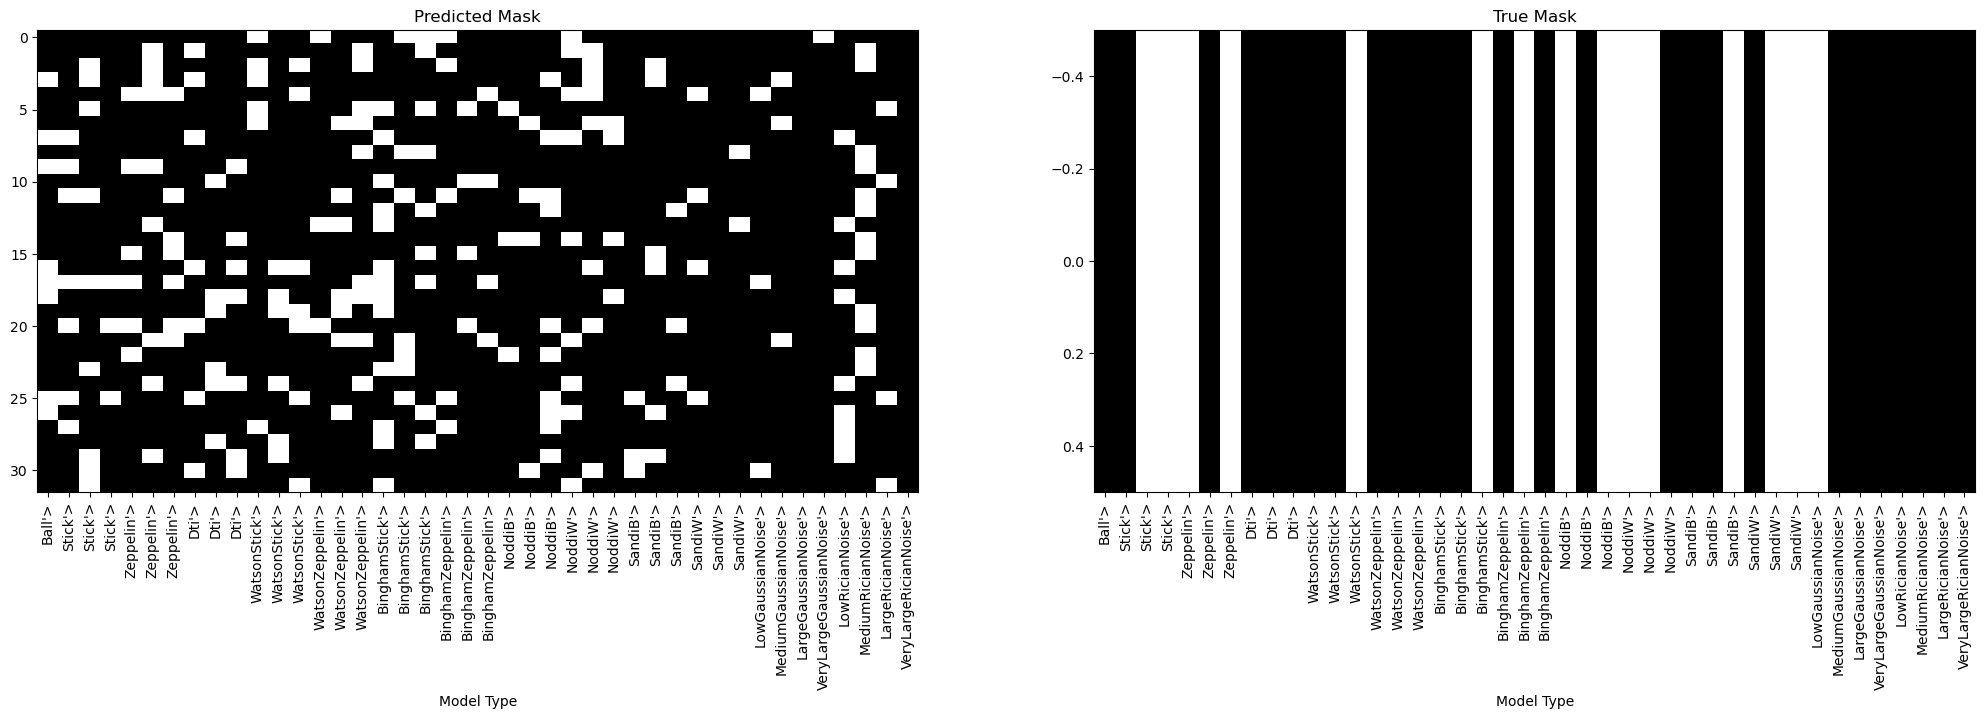

In [51]:
plt.figure(figsize=(25, 6))

# Plot predicted mask
plt.subplot(1, 2, 1)
plt.imshow(mask, aspect='auto', cmap='gray', vmin=0, vmax=1)
plt.title('Predicted Mask')
plt.xlabel('Model Type')
plt.xticks(range(len(AllGaussianAndConvolvedModels.model_types) + len(AllGaussianAndConvolvedModels.noise_types)), [str(m).split(".")[-1] for m in AllGaussianAndConvolvedModels.model_types] + [str(m).split(".")[-1] for m in AllGaussianAndConvolvedModels.noise_types], rotation=90)

# Plot true mask
mask_true = masks[idx]
plt.subplot(1, 2, 2)
plt.imshow(mask_true[None], aspect='auto', cmap='gray', vmin=0, vmax=1)
plt.title('True Mask')
plt.xlabel('Model Type')
plt.xticks(range(len(AllGaussianAndConvolvedModels.model_types) + len(AllGaussianAndConvolvedModels.noise_types)), [str(m).split(".")[-1] for m in AllGaussianAndConvolvedModels.model_types] + [str(m).split(".")[-1] for m in AllGaussianAndConvolvedModels.noise_types], rotation=90)

plt.show()

In [52]:
from functools import partial

In [55]:
from dmri.utils.eval import run_tarp
alphas, masks, thetas, x_os, acq = batch_simulator(jax.random.split(jax.random.key(1), 1000))
_sample_theta_batched =jax.vmap(partial(model.sample_theta, num_steps=32, max_noise=40), in_axes=(None,0,0, 0,0))
_sample_theta_batched_batched = jax.vmap(_sample_theta_batched, in_axes=(0,None,None, None, None))

thetas_per_obs = _sample_theta_batched_batched(jax.random.split(jax.random.key(0), 128), acq.bvals, acq.bvecs, x_os, masks)

(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41)


In [56]:
thetas_per_obs.shape

(128, 1000, 243)

(128, 1000) (1000,)


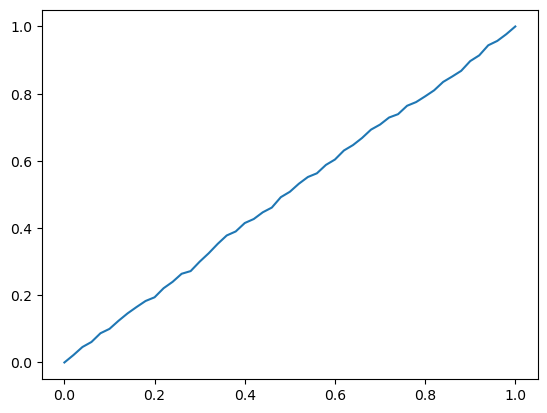

In [57]:
ecd, alpha = run_tarp(thetas, thetas_per_obs, num_bins=50)

plt.plot(alpha,ecd)

In [104]:
idx = 5

In [105]:
thetas_post = jax.vmap(partial(model.sample_theta, num_steps=64, max_noise=20), in_axes=(0,None,None, None, None,))(jax.random.split(jax.random.key(0), 1024), acq.bvals[idx], acq.bvecs[idx], x_os[idx],masks[idx])

(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41)


In [106]:
# import sbi
# from sbi.analysis.plot import pairplot

# _ = pairplot(thetas_post, points=[thetas[idx],], limits=[[-3,3]*100], labels=[f'$\\theta_{i}$' for i in range(100)], figsize=(25, 25))

In [107]:
def posterior_pred(theta,rng):
    return AllGaussianAndConvolvedModels.from_theta(theta, model_mask=masks[idx]).signal(acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), rng=rng)

posterior_preds = jax.vmap(posterior_pred)(thetas_post, jax.random.split(jax.random.key(0), 1024))

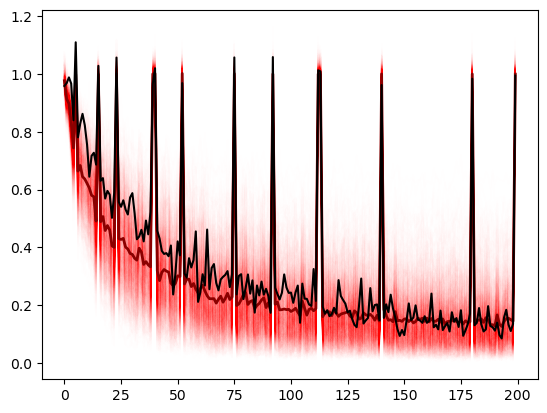

In [108]:
_ = plt.plot(posterior_preds.T, label="posterior pred", color="red", alpha=0.005)
_ = plt.plot(posterior_preds.mean(0).T, label="posterior pred mean", color="darkred", linewidth=2)
_ = plt.plot(x_os[idx], label="data", color="black")